# Introduction: AI, Machine Learning, and Deep Learning

<div dir=rtl>

## היסטוריה, על קצה המזלג

אם ננסה לשרטט ציר זמן שמתאר את התפתחות הבינה המלאכותית, למידת המכונה ורשתות הנוירונים, הוא יראה בערך ככה:

</div>

<center>
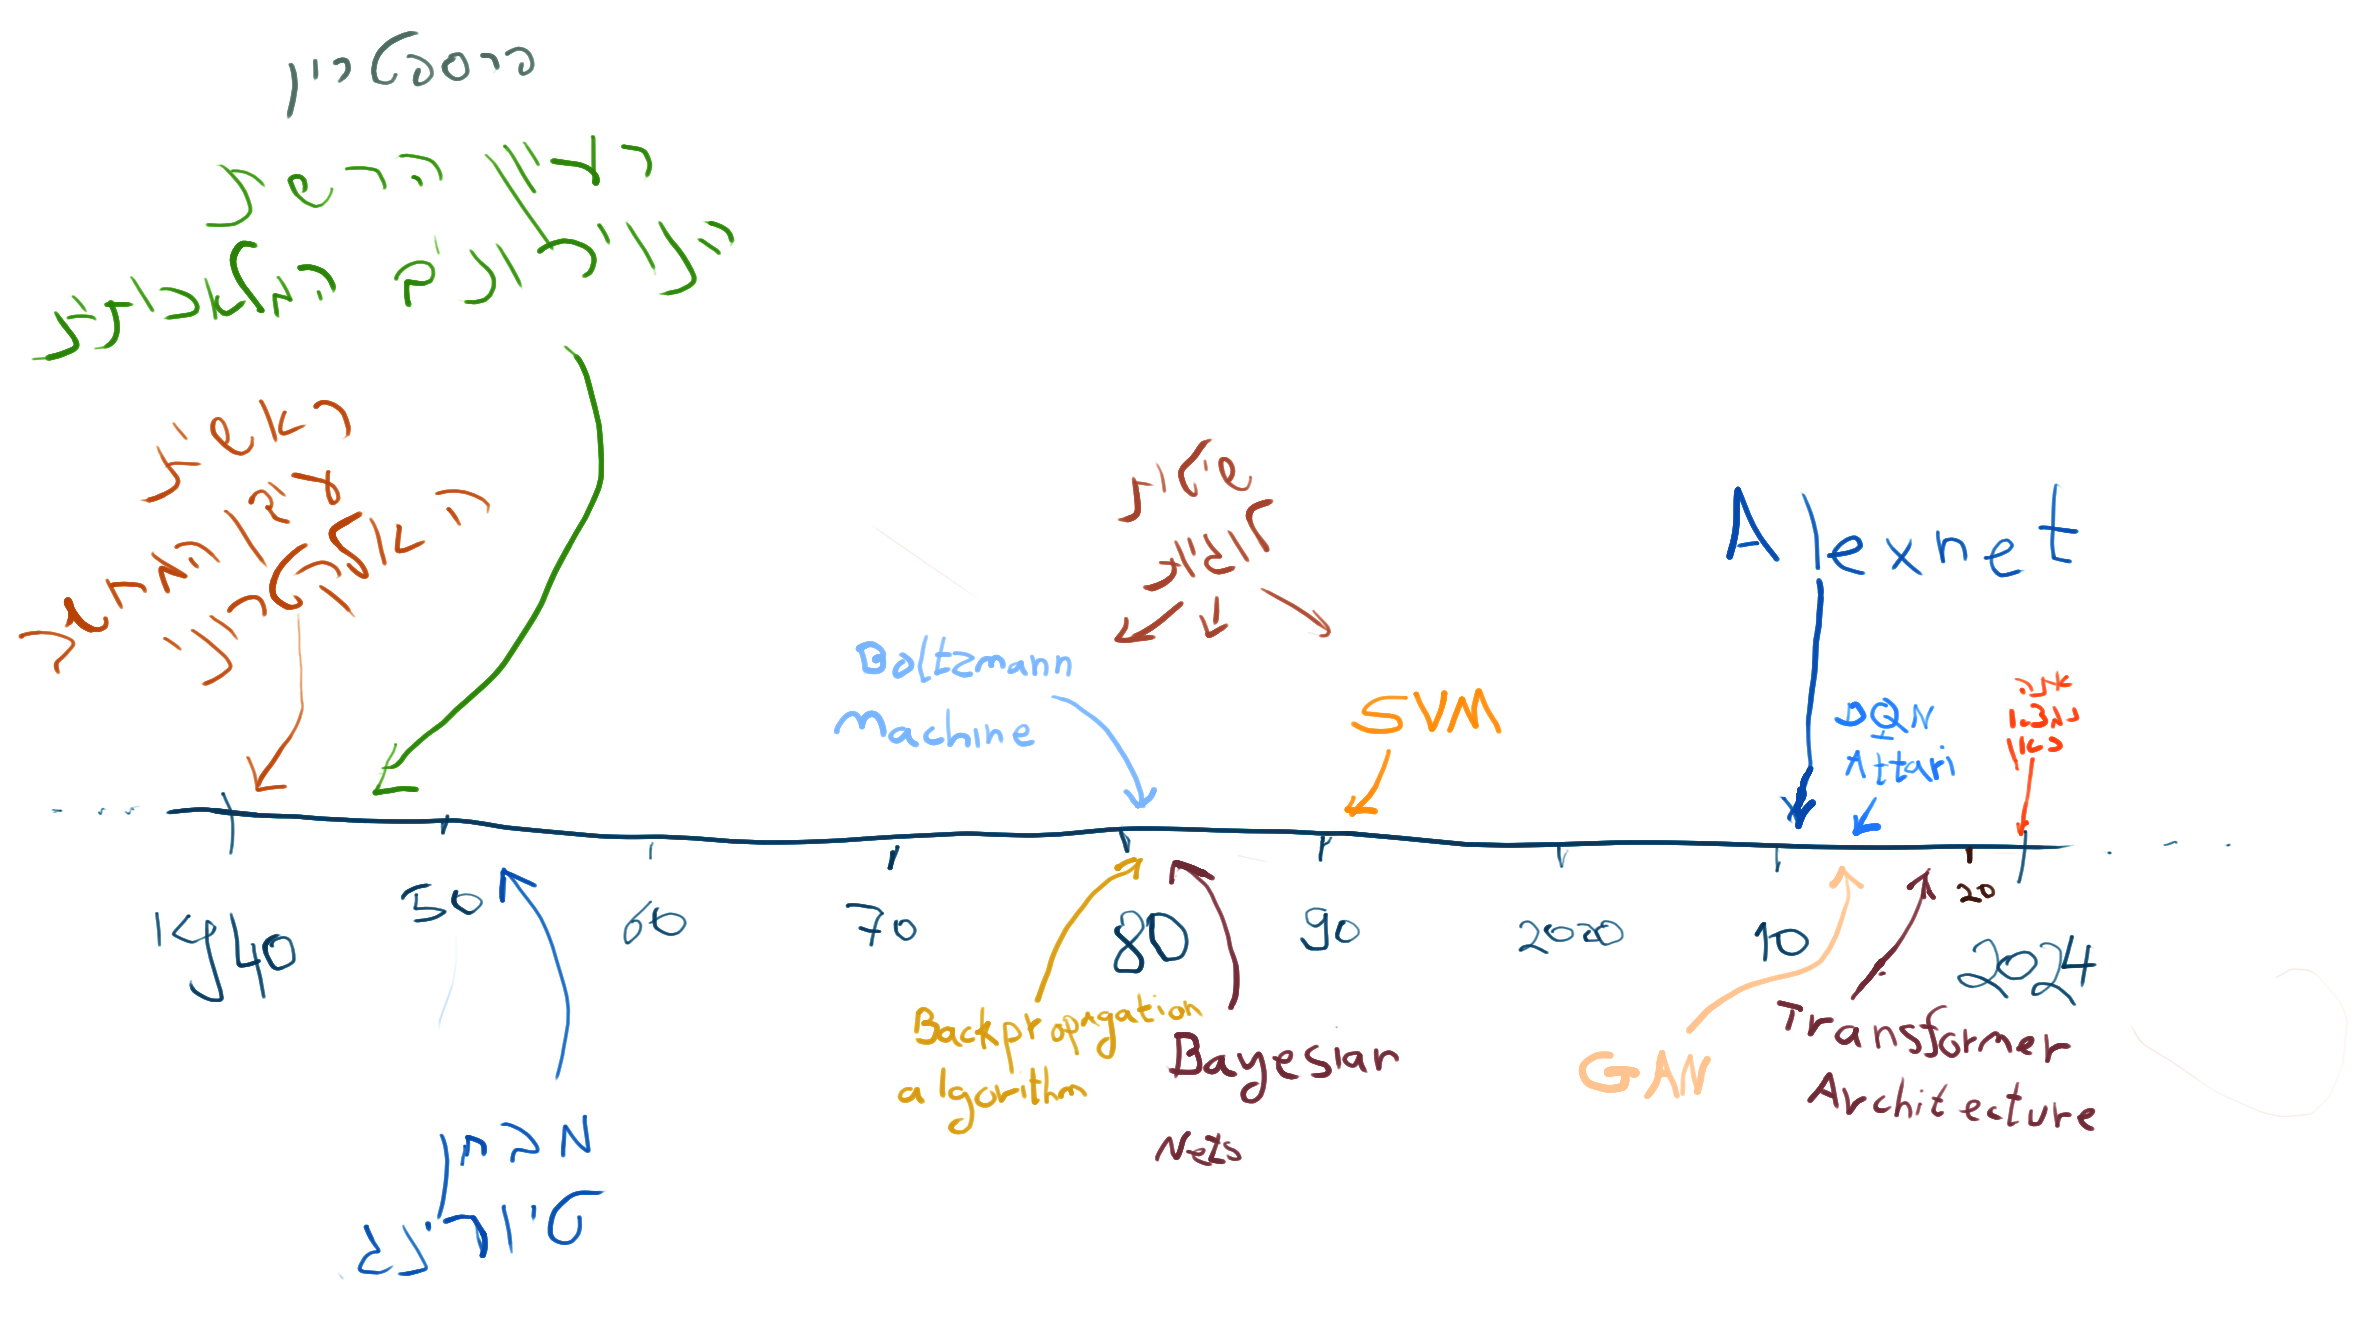
</center>

<div dir=rtl>

אפשר לראות שהרעיון של רשתות נוירונים הוא מוקדם מאוד — משנות ה-40 של המאה הקודמת.
הרבה שנים ניסו רעיונות אחרים, אבל בעשור האחרון רשתות הנוירונים חזרו ונהיו דומיננטיות מאוד.

הקורס הזה יתרכז בלמידת מכונה באמצעות רשתות נוירונים מלאכותיות — מה שנהוג לכנות היום **למידה עמוקה**.

</div>

<div dir=rtl>

## סדר במושגים

שלושה מושגים שנשמעים לפעמים לסירוגין, אבל מדברים על דברים שונים:

**בינה מלאכותית — Artificial Intelligence**  
שם עממי לתוכניות מחשב שמבצעות פעולות שבדרך כלל מיוחסות לאינטליגנציה אנושית:  
מציאת מוצא במבוך, הבנת דיבור, נהיגה אוטונומית, הסקה מתמטית...  
המושג הוא כללי ולא מדבר על *איך* ממומשות הפעולות — רק על *מה* הן עושות.

**למידת מכונה — Machine Learning**  
תת-תחום של בינה מלאכותית. תוכניות שלומדות ומשתפרות — מנתונים שנותנים להן, או מניסיון של עצמן.

**למידה עמוקה — Deep Learning**  
טכניקה מסוימת של למידת מכונה, שמשתמשת ברשתות נוירונים עמוקות.  
הטכניקה הזו צברה בשנים האחרונות הצלחות גדולות, ואפשר להגיד שהיא המובילה כיום.

</div>

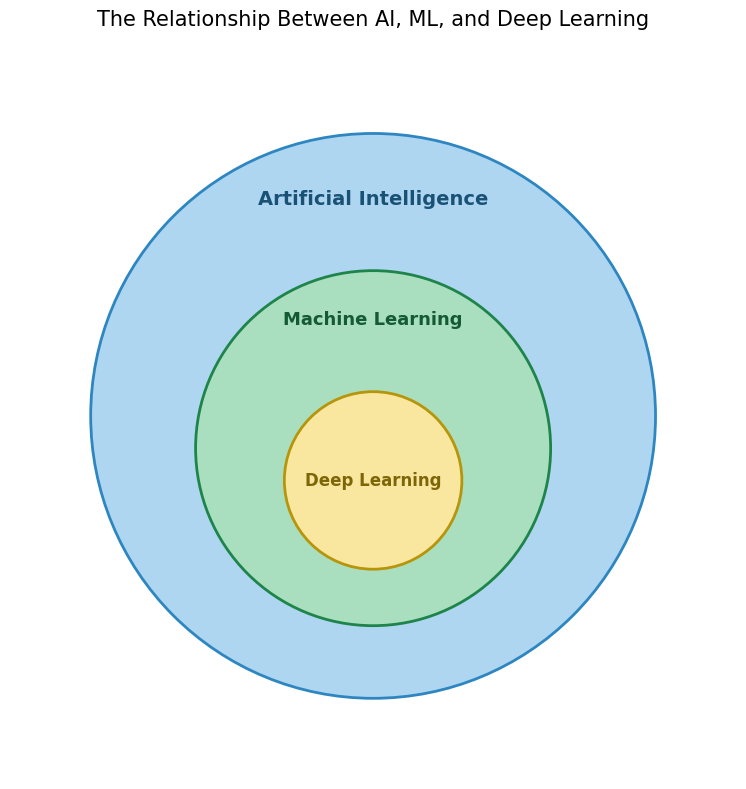

In [1]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 8))

ai = plt.Circle((0, 0), 3.5, color='#AED6F1', ec='#2E86C1', linewidth=2)
ml = plt.Circle((0, -0.4), 2.2, color='#A9DFBF', ec='#1E8449', linewidth=2)
dl = plt.Circle((0, -0.8), 1.1, color='#F9E79F', ec='#B7950B', linewidth=2)

ax.add_patch(ai)
ax.add_patch(ml)
ax.add_patch(dl)

ax.text(0, 2.7, 'Artificial Intelligence', ha='center', va='center',
        fontsize=14, fontweight='bold', color='#1A5276')
ax.text(0, 1.2, 'Machine Learning', ha='center', va='center',
        fontsize=13, fontweight='bold', color='#145A32')
ax.text(0, -0.8, 'Deep Learning', ha='center', va='center',
        fontsize=12, fontweight='bold', color='#7D6608')

ax.set_xlim(-4.5, 4.5)
ax.set_ylim(-4.5, 4.5)
ax.set_aspect('equal')
ax.axis('off')
plt.title('The Relationship Between AI, ML, and Deep Learning', fontsize=15, pad=20)
plt.tight_layout()
plt.show()

<div dir=rtl>

## קטגוריות של בעיות בלמידת מכונה

נהוג לחלק את הבעיות שפותרים בעזרת למידת מכונה לשלוש קטגוריות עיקריות:

- **למידה מונחית** — Supervised learning
- **למידה לא מונחית** — Unsupervised learning
- **למידת חיזוק** — Reinforcement learning

בכל אחת מהקטגוריות אפשר להשתמש גם בשיטות של למידה עמוקה.

</div>

<center>
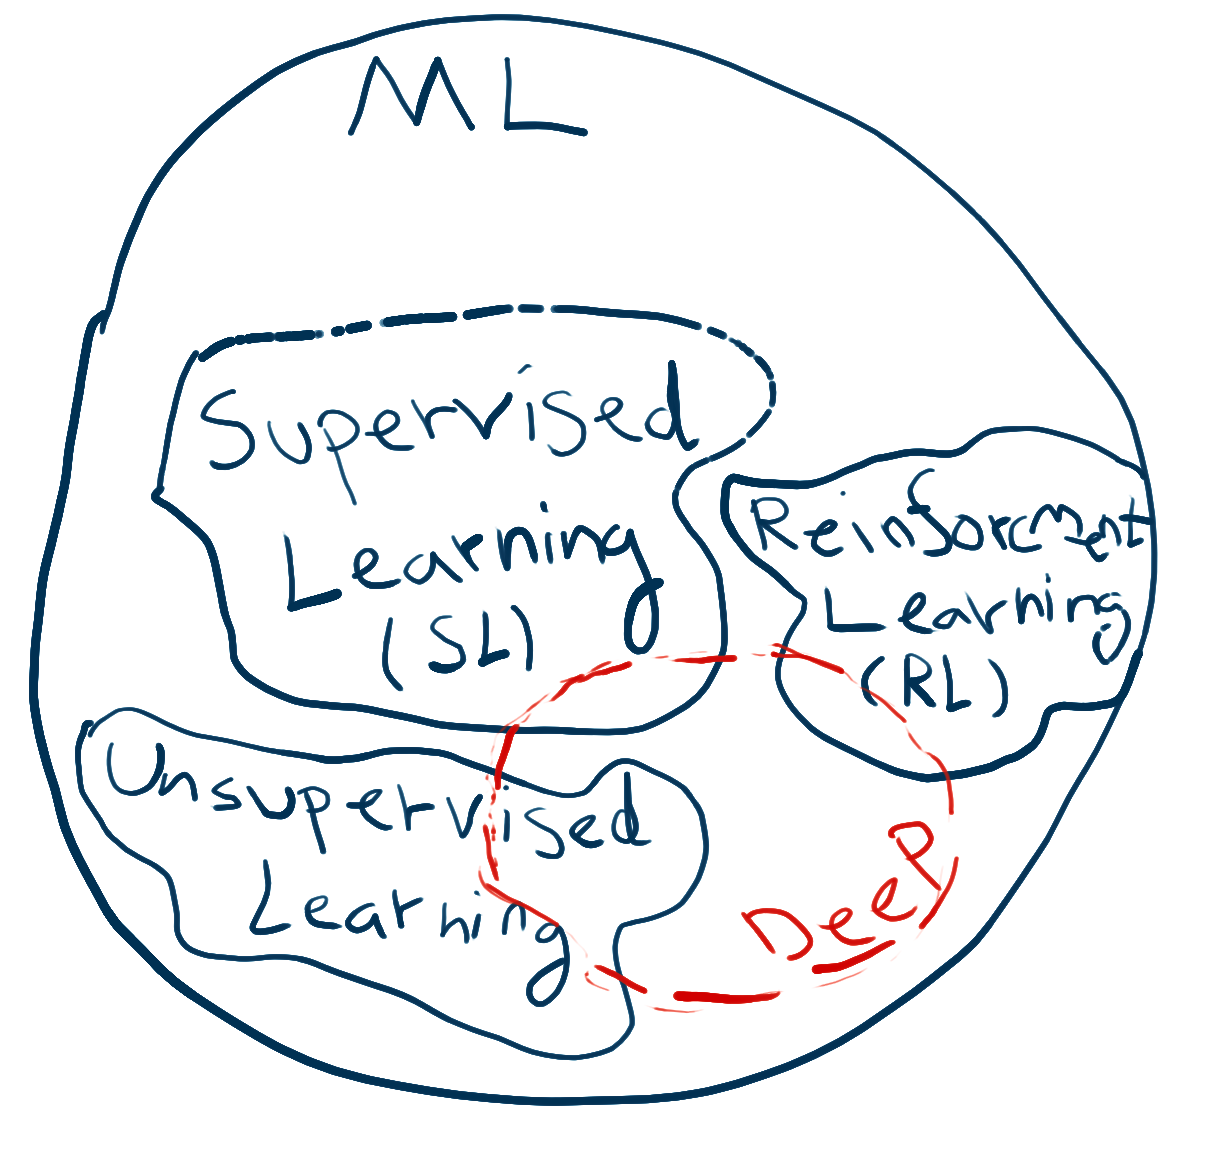
</center>

<div dir=rtl>

### למידה מונחית — Supervised Learning

**למידה מונחית** היא למידה שבה הקלט לאלגוריתם הוא אוסף של **זוגות: דוגמה והפתרון הנכון שלה**.

דוגמה: זיהוי ספרות בכתב יד (OCR).  
האלגוריתם מקבל זוגות של תמונה (X) והספרה שכתובה בה (Y), וצריך ללמוד את חוק ההתאמה ביניהם.

הלמידה נקראת "מונחית" כי אנחנו מספקים את התשובה הנכונה לכל דוגמה — מנחים את האלגוריתם.

</div>

<div dir=rtl>

ה-dataset שנקרא [MNIST](https://en.wikipedia.org/wiki/MNIST_database) הוא אוסף מפורסם של תמונות מתויגות של ספרות בכתב יד.

כמה נתונים על המאגר:
- **60,000** דוגמאות אימון, **10,000** דוגמאות בדיקה
- כל תמונה: **28×28 פיקסלים**, גווני אפור
- כל תמונה מתויגת עם הספרה האמיתית (0–9)

הריצו את התא הבא ושחקו עם הסליידר:

</div>

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

(train_x, train_y), _ = tf.keras.datasets.mnist.load_data()

def show_examples(start_idx):
    n = 8
    fig, axes = plt.subplots(1, n, figsize=(14, 2.5))
    fig.suptitle(f'MNIST — examples #{start_idx}–{start_idx+n-1}     X = image  |  Y = label',
                 fontsize=11, y=1.08)
    for i, ax in enumerate(axes):
        ax.imshow(train_x[start_idx + i], cmap='binary')
        ax.set_title(f'Y = {train_y[start_idx + i]}', fontsize=13)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

slider = widgets.IntSlider(
    value=0, min=0, max=len(train_x) - 8, step=8,
    description='Example #',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='600px')
)
widgets.interact(show_examples, start_idx=slider)

ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

(train_x, train_y), (test_x, test_y) = tf.keras.datasets.mnist.load_data()

print(f'Training examples:  {len(train_x):,}')
print(f'Testing examples:   {len(test_x):,}')
print(f'Image size:         {train_x[0].shape[0]}×{train_x[0].shape[1]} pixels')
print(f'As a flat vector:   {train_x[0].shape[0] * train_x[0].shape[1]} elements')

fig, ax = plt.subplots(figsize=(8, 3))
counts = np.bincount(train_y)
ax.bar(range(10), counts, color='#AED6F1', edgecolor='#2E86C1', linewidth=1.5)
ax.set_xticks(range(10))
ax.set_xlabel('Digit')
ax.set_ylabel('Count')
ax.set_title('Distribution of digits in the training set')
plt.tight_layout()
plt.show()

<div dir=rtl>

### למידה לא מונחית — Unsupervised Learning

בלמידה לא מונחית, האלגוריתם מקבל רק דוגמאות — **בלי תשובות נכונות**. רק X, בלי Y.

מה אפשר ללמוד בלי שאמרנו לאלגוריתם מה אנחנו רוצים?  
הוא יכול ללמוד **מבניות פנימיות** — דפוסים, קבוצות, חוקיות סמויה.

דוגמה: מודל שפה כמו GPT מאומן על כמויות עצומות של טקסט מהאינטרנט, **בלי תיוגים**.  
מתוך הכמות האדירה, הוא בונה ייצוג פנימי של השפה והידע האנושי.

בקורס הזה נדבר מעט על למידה לא מונחית.

</div>

<div dir=rtl>

### למידת חיזוק — Reinforcement Learning

למידת חיזוק היא למידה **בסביבה מתגמלת**. בסטינג הזה:
- יש **סוכן** — האלגוריתם הלומד
- יש **סביבה** שבה הסוכן פועל
- הסוכן בוחר **פעולות**
- הסביבה מחזירה **תגמול (reward) ותצפית** אחרי כל פעולה

</div>

<div dir=rtl>

אפשר לראות שהסוכן לומד אסטרטגיה לא טריוויאלית לחלוטין — בלי שהסברנו לו כלום.

שנים ספורות אחר כך, אותה חברה הצליחה ליצור אלגוריתם שניצח את **אלוף העולם במשחק גו** —  
משחק שנחשב קשה בהרבה מחמת-מלך.  
([הנה סרט תיעודי מרתק על זה](https://www.youtube.com/watch?v=WXuK6gekU1Y))

בקורס הזה לא נעסוק בלמידת חיזוק, אבל חשוב להכיר שהיא קיימת ושהיא עוצמתית מאוד.

</div>

In [ ]:
from IPython.display import IFrame, display
display(IFrame('https://www.youtube.com/embed/TmPfTpjtdgg', width=700, height=400))

<div dir=rtl>

דוגמה קלאסית: לימוד משחקי מחשב.

חברת [DeepMind](https://en.wikipedia.org/wiki/Google_DeepMind) לימדה סוכן לשחק [Breakout](https://en.wikipedia.org/wiki/Breakout_(video_game)) — משחק אטרי משנות ה-70.  
הסוכן **לא קיבל שום הסבר** על כללי המשחק. כל מה שנתנו לו: תמונת המסך + הניקוד, בכל רגע.

הסרטון הבא מדגים את תהליך הלמידה:

</div>

<center>
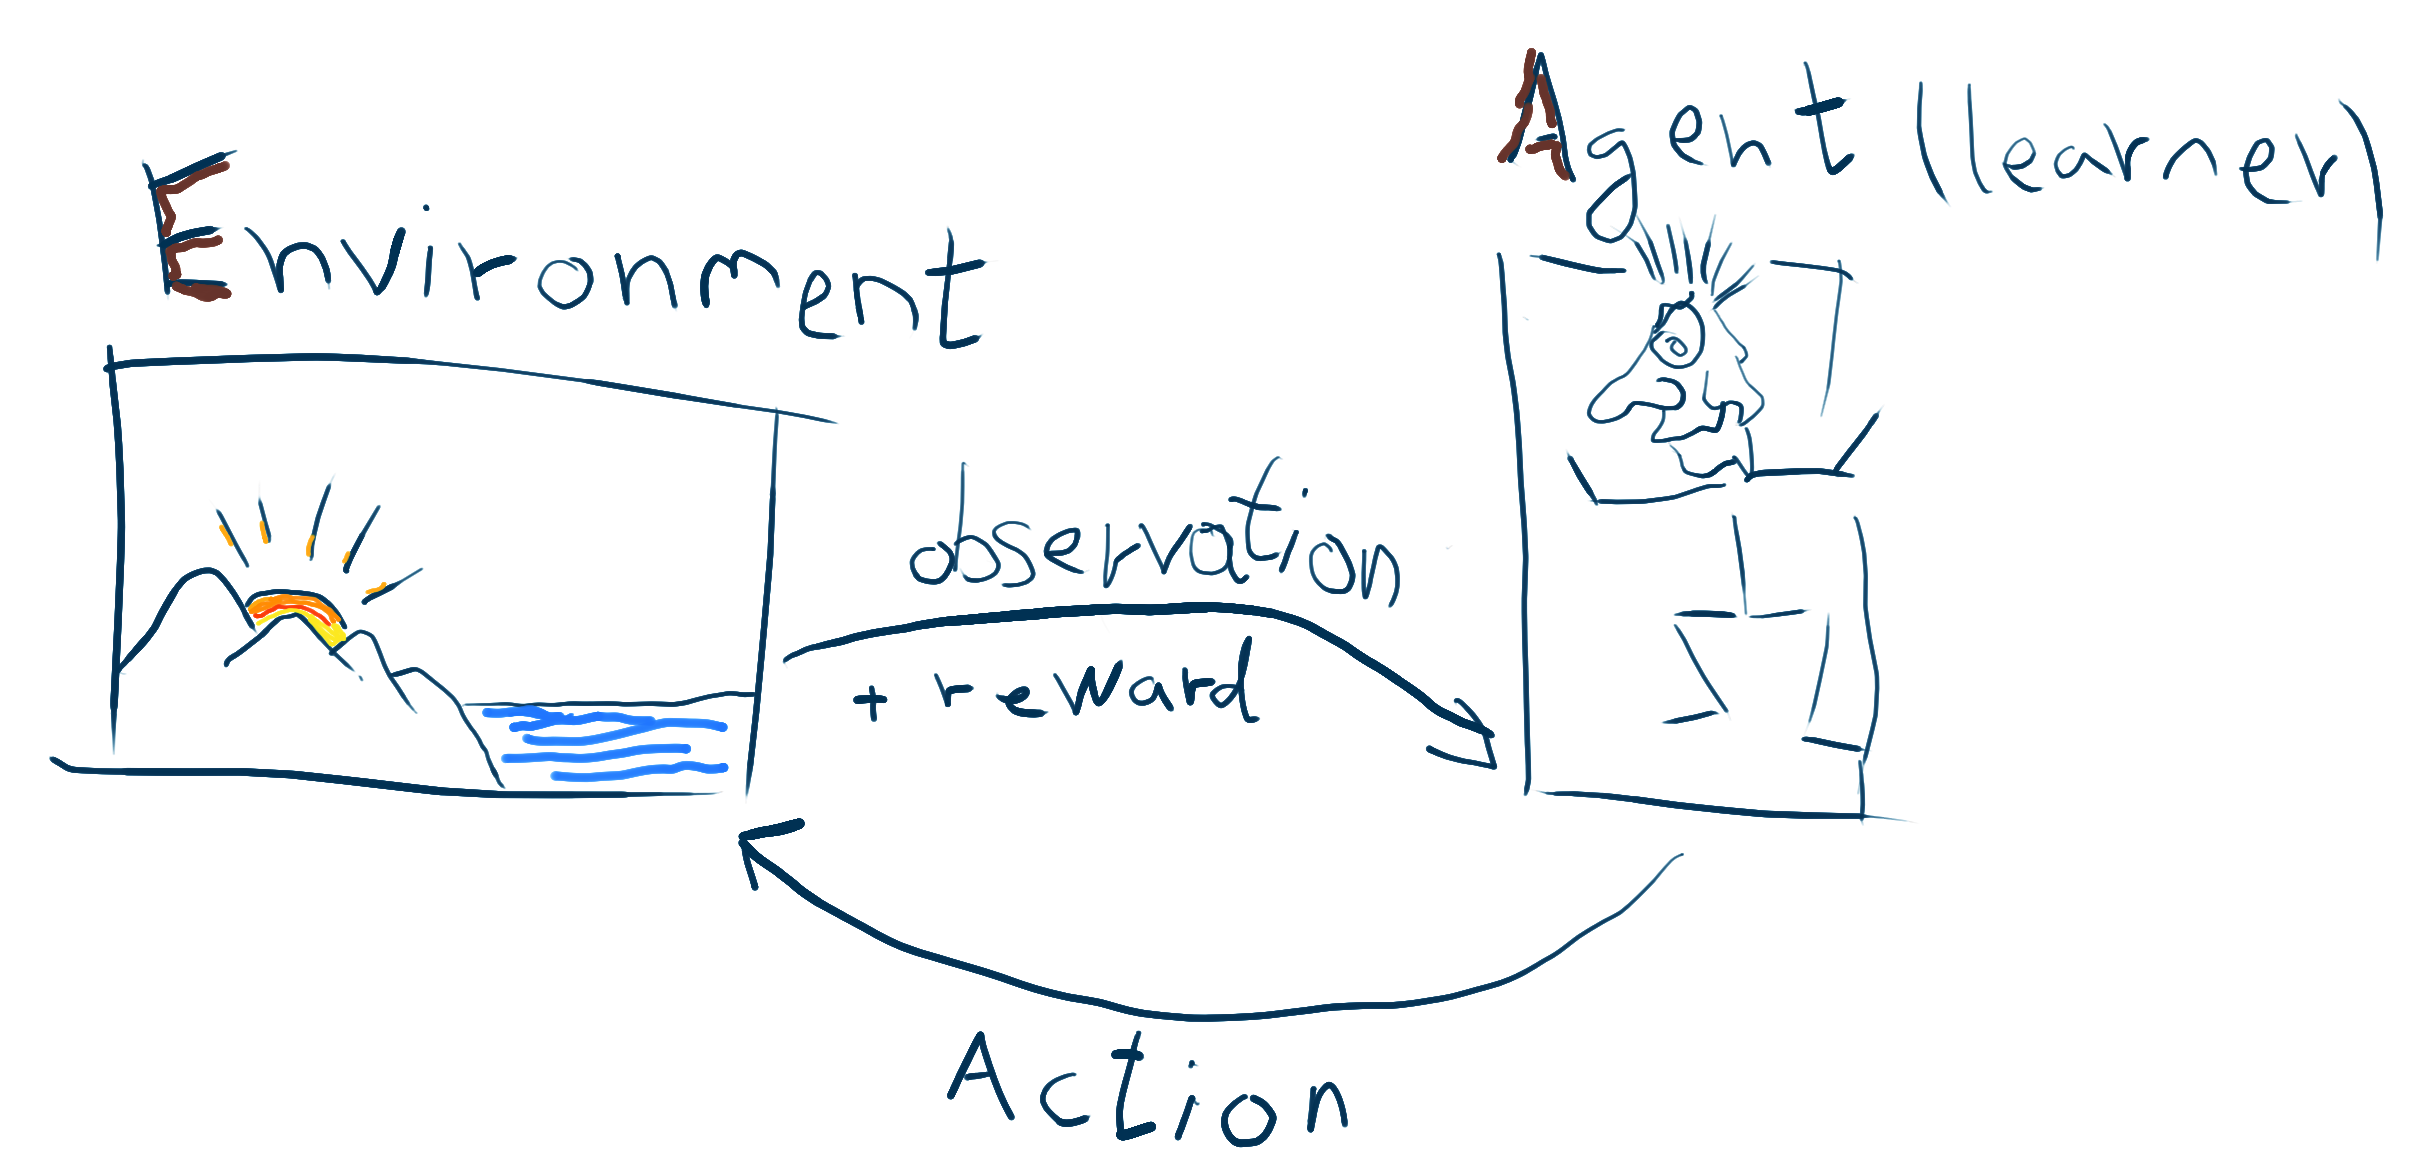
</center>